# 09 ? Ridge Residuals vs Edge-Discretization Diagnostics

Step 07 established physical sanity checks for the fixed discrete-n superellipse dataset, and step 08 kept physics-informed Ridge as the preferred model after the tiny MLP ablation. This notebook analyzes where the preferred Ridge model still makes out-of-fold errors.

The goal is diagnostic interpretation, not model tuning. No datasets are created or modified, the baseline model is not changed, and MLP residuals are not used for the main conclusion.

In [1]:
from __future__ import annotations

import csv
import math
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from scipy.stats import spearmanr

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.model import build_baseline_model, make_ablation_feature_matrix

DATA_PATH = PROJECT_ROOT / "data" / "superellipse_discrete_n_dense_dataset.npz"
PHYSICS_DIAGNOSTICS_PATH = PROJECT_ROOT / "reports" / "physics_sanity_checks.csv"
OOF_RESIDUALS_PATH = PROJECT_ROOT / "reports" / "ridge_oof_point_residuals.csv"
CORRELATIONS_PATH = PROJECT_ROOT / "reports" / "ridge_residual_correlations.csv"
COLLINEARITY_PATH = PROJECT_ROOT / "reports" / "ridge_residual_predictor_collinearity.csv"
HYPOTHESIS_SUMMARY_PATH = PROJECT_ROOT / "reports" / "ridge_residual_hypothesis_summary.csv"
ASSET_DIR = PROJECT_ROOT / "reports" / "assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

N_VALUES = [1.2, 2.0, 3.0, 4.0]
TARGETS = ["E0", "dE1"]
PROTOCOLS = {"LOAO": "a", "LOARO": "aspect_ratio"}
DISCRETIZATION_VARIABLES = ["edge_area_error_abs", "imbalance_ratio"]
SMOOTH_VARIABLES = ["a", "aspect_ratio"]
PREDICTOR_VARIABLES = DISCRETIZATION_VARIABLES + SMOOTH_VARIABLES
PRIMARY_TARGET = "E0"
PRIMARY_PROTOCOL = "LOAO"
MEANINGFUL_RHO_THRESHOLD = 0.3
HIGH_COLLINEARITY_THRESHOLD = 0.7

plt.rcParams.update({"figure.figsize": (8.0, 4.8), "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")
print(f"Physics diagnostics path: {PHYSICS_DIAGNOSTICS_PATH}")

Project root: D:\Diplom Physcis ML\Diplom Physcis ML
Dataset path: D:\Diplom Physcis ML\Diplom Physcis ML\data\superellipse_discrete_n_dense_dataset.npz
Physics diagnostics path: D:\Diplom Physcis ML\Diplom Physcis ML\reports\physics_sanity_checks.csv


In [2]:
with np.load(DATA_PATH) as raw_data:
    dataset_keys = list(raw_data.files)
    data = {key: raw_data[key].copy() for key in dataset_keys}

with PHYSICS_DIAGNOSTICS_PATH.open(newline="", encoding="utf-8") as f:
    physics_reader = csv.DictReader(f)
    physics_rows = list(physics_reader)
    physics_columns = list(physics_reader.fieldnames or [])

print(f"number of samples: {len(data['a'])}")
print(f"unique n: {np.unique(data['n'])}")
print(f"unique a: {np.unique(data['a'])}")
print(f"unique aspect_ratio: {np.unique(data['aspect_ratio'])}")
print(f"available diagnostics from physics_sanity_checks.csv: {physics_columns}")

number of samples: 140
unique n: [1.2 2.  3.  4. ]
unique a: [24. 27. 30. 33. 36.]
unique aspect_ratio: [0.67 0.72 0.78 0.83 0.89 0.94 1.  ]
available diagnostics from physics_sanity_checks.csv: ['n', 'a', 'aspect_ratio', 'N_sites', 'E0', 'E1', 'E2', 'E3', 'dE1', 'dE2', 'dE3', 'E_kin', 'scaled_E0', 'scaled_dE1', 'analytic_area', 'N_sites_over_area', 'R_eff', 'E_Bessel', 'bessel_relative_error', 'N_A', 'N_B', 'delta_N', 'imbalance_ratio']


## Merge dataset and diagnostics

The analysis table combines the saved NPZ dataset with diagnostics from `reports/physics_sanity_checks.csv`, keyed by `n`, `a`, and `aspect_ratio`. The step-07 diagnostics provide site-count, analytic-area, and sublattice quantities.

In [3]:
def key3(n: float, a: float, aspect_ratio: float) -> tuple[float, float, float]:
    return (round(float(n), 10), round(float(a), 10), round(float(aspect_ratio), 10))

def parse_float(value: object) -> float:
    return float(value)

def is_nan(value: object) -> bool:
    try:
        return math.isnan(float(value))
    except (TypeError, ValueError):
        return False

def isclose_value(value: float, expected: float) -> bool:
    return math.isclose(float(value), float(expected), rel_tol=0.0, abs_tol=1e-9)

def select_rows(rows: list[dict[str, object]], **conditions: object) -> list[dict[str, object]]:
    out = rows
    for key, expected in conditions.items():
        if isinstance(expected, str):
            out = [row for row in out if row[key] == expected]
        else:
            out = [row for row in out if isclose_value(float(row[key]), float(expected))]
    return out

def column(rows: list[dict[str, object]], name: str) -> np.ndarray:
    return np.array([float(row[name]) for row in rows], dtype=float)

def spearman_or_nan(x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]; y = y[mask]
    if x.size < 3 or y.size < 3 or np.unique(x).size < 2 or np.unique(y).size < 2:
        return math.nan, math.nan
    result = spearmanr(x, y)
    return float(result.statistic), float(result.pvalue)

def max_abs_row(rows: list[dict[str, object]]) -> dict[str, object] | None:
    valid = [row for row in rows if not is_nan(row["abs_spearman_rho"])]
    return None if not valid else max(valid, key=lambda row: float(row["abs_spearman_rho"]))

def csv_clean(value: object) -> object:
    if isinstance(value, (float, np.floating)) and math.isnan(float(value)):
        return "NaN"
    if isinstance(value, (bool, np.bool_)):
        return str(bool(value))
    return value

def write_csv(path: Path, rows: list[dict[str, object]], columns: list[str]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=columns)
        writer.writeheader()
        for row in rows:
            writer.writerow({c: csv_clean(row.get(c, math.nan)) for c in columns})

def markdown_table(records: list[dict[str, object]], columns: list[str], max_rows: int | None = None) -> None:
    shown = records if max_rows is None else records[:max_rows]
    lines = ["| " + " | ".join(columns) + " |", "| " + " | ".join(["---"] * len(columns)) + " |"]
    for record in shown:
        values = []
        for col in columns:
            value = record[col]
            if isinstance(value, (float, np.floating)):
                values.append("NaN" if math.isnan(float(value)) else f"{float(value):.6g}")
            else:
                values.append(str(value))
        lines.append("| " + " | ".join(values) + " |")
    if max_rows is not None and len(records) > max_rows:
        lines.append(f"\nShowing {max_rows} of {len(records)} rows.")
    display(Markdown("\n".join(lines)))

required_diagnostic_columns = ["N_sites", "analytic_area", "N_sites_over_area", "N_A", "N_B", "delta_N", "imbalance_ratio"]
physics_lookup = {key3(row["n"], row["a"], row["aspect_ratio"]): row for row in physics_rows}
base_rows: list[dict[str, object]] = []
for idx in range(len(data["a"])):
    n_value = float(data["n"][idx]); a_value = float(data["a"][idx]); ar_value = float(data["aspect_ratio"][idx])
    physics_row = physics_lookup[key3(n_value, a_value, ar_value)]
    merged = {"n": n_value, "a": a_value, "aspect_ratio": ar_value, "E0": float(data["E0"][idx]), "dE1": float(data["dE1"][idx])}
    for diagnostic in required_diagnostic_columns:
        merged[diagnostic] = parse_float(physics_row[diagnostic])
    merged["edge_area_error_signed"] = merged["N_sites_over_area"] - 1.0
    merged["edge_area_error_abs"] = abs(merged["edge_area_error_signed"])
    merged["abs_delta_N_over_N"] = abs(merged["delta_N"]) / merged["N_sites"]
    base_rows.append(merged)
print(f"Merged analysis table rows: {len(base_rows)}")
print(f"Required diagnostics present: {required_diagnostic_columns}")
markdown_table(base_rows[:8], ["n", "a", "aspect_ratio", "E0", "dE1", "N_sites", "N_sites_over_area", "imbalance_ratio"], max_rows=8)

Merged analysis table rows: 140
Required diagnostics present: ['N_sites', 'analytic_area', 'N_sites_over_area', 'N_A', 'N_B', 'delta_N', 'imbalance_ratio']


| n | a | aspect_ratio | E0 | dE1 | N_sites | N_sites_over_area | imbalance_ratio |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1.2 | 24 | 0.67 | -3.97866 | 0.0250564 | 905 | 0.996882 | 0.00110497 |
| 2 | 24 | 0.67 | -3.98445 | 0.0166055 | 1205 | 0.993894 | 0.00414938 |
| 3 | 24 | 0.67 | -3.98603 | 0.0143164 | 1357 | 0.995187 | 0.0036846 |
| 4 | 24 | 0.67 | -3.98658 | 0.0136939 | 1425 | 0.995773 | 0.00491228 |
| 1.2 | 24 | 0.72 | -3.98077 | 0.0235485 | 983 | 1.00761 | 0.0111902 |
| 2 | 24 | 0.72 | -3.98596 | 0.016261 | 1303 | 1.00009 | 0.0038373 |
| 3 | 24 | 0.72 | -3.98733 | 0.0141889 | 1459 | 0.995686 | 0.00479781 |
| 4 | 24 | 0.72 | -3.9878 | 0.0134782 | 1535 | 0.998151 | 0.0019544 |

## Point-level out-of-fold Ridge residuals

For each fixed `n`, target, and structured protocol, the physics-informed Ridge model is trained on all but one group and predicts the held-out geometries. Residuals are `y_pred - y_true`, saved one row per held-out geometry.

In [4]:
oof_rows: list[dict[str, object]] = []
for n_value in N_VALUES:
    n_rows = select_rows(base_rows, n=n_value)
    a_values = column(n_rows, "a")
    ar_values = column(n_rows, "aspect_ratio")
    features = make_ablation_feature_matrix(a_values, ar_values, feature_set="physics_informed")
    for target in TARGETS:
        y = column(n_rows, target)
        for protocol, group_key in PROTOCOLS.items():
            groups = column(n_rows, group_key)
            for left_out_group in np.unique(groups):
                test_mask = groups == left_out_group
                train_mask = ~test_mask
                model = build_baseline_model("ridge")
                model.fit(features[train_mask], y[train_mask])
                pred = np.asarray(model.predict(features[test_mask]), dtype=float)
                for local_idx, y_pred in zip(np.where(test_mask)[0], pred):
                    source = n_rows[int(local_idx)]
                    y_true = float(source[target])
                    residual = float(y_pred - y_true)
                    oof_rows.append({
                        "n": n_value, "target": target, "protocol": protocol, "left_out_group": float(left_out_group),
                        "a": source["a"], "aspect_ratio": source["aspect_ratio"], "y_true": y_true, "y_pred": float(y_pred),
                        "residual": residual, "abs_residual": abs(residual), "squared_residual": residual**2,
                        "N_sites": source["N_sites"], "analytic_area": source["analytic_area"], "N_sites_over_area": source["N_sites_over_area"],
                        "edge_area_error_signed": source["edge_area_error_signed"], "edge_area_error_abs": source["edge_area_error_abs"],
                        "N_A": source["N_A"], "N_B": source["N_B"], "delta_N": source["delta_N"],
                        "imbalance_ratio": source["imbalance_ratio"], "abs_delta_N_over_N": source["abs_delta_N_over_N"],
                    })
OOF_COLUMNS = ["n", "target", "protocol", "left_out_group", "a", "aspect_ratio", "y_true", "y_pred", "residual", "abs_residual", "squared_residual", "N_sites", "analytic_area", "N_sites_over_area", "edge_area_error_signed", "edge_area_error_abs", "N_A", "N_B", "delta_N", "imbalance_ratio", "abs_delta_N_over_N"]
write_csv(OOF_RESIDUALS_PATH, oof_rows, OOF_COLUMNS)
print(f"Saved: {OOF_RESIDUALS_PATH}")
print(f"Rows: {len(oof_rows)}")
markdown_table(oof_rows[:8], ["n", "target", "protocol", "left_out_group", "a", "aspect_ratio", "residual", "abs_residual"], max_rows=8)

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\ridge_oof_point_residuals.csv
Rows: 560


| n | target | protocol | left_out_group | a | aspect_ratio | residual | abs_residual |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1.2 | E0 | LOAO | 24 | 24 | 0.67 | -0.00125736 | 0.00125736 |
| 1.2 | E0 | LOAO | 24 | 24 | 0.72 | -0.00034009 | 0.00034009 |
| 1.2 | E0 | LOAO | 24 | 24 | 0.78 | -2.13158e-05 | 2.13158e-05 |
| 1.2 | E0 | LOAO | 24 | 24 | 0.83 | 0.000192947 | 0.000192947 |
| 1.2 | E0 | LOAO | 24 | 24 | 0.89 | 0.000311537 | 0.000311537 |
| 1.2 | E0 | LOAO | 24 | 24 | 0.94 | 0.000443352 | 0.000443352 |
| 1.2 | E0 | LOAO | 24 | 24 | 1 | 0.000144983 | 0.000144983 |
| 1.2 | E0 | LOAO | 27 | 27 | 0.67 | -0.000563117 | 0.000563117 |

## Predictor collinearity analysis

For every target/protocol/n subset, compute Spearman correlations among the four independent predictors before interpreting residual correlations.

In [5]:
collinearity_rows: list[dict[str, object]] = []
for target in TARGETS:
    for protocol in PROTOCOLS:
        for n_value in N_VALUES:
            subset = select_rows(oof_rows, target=target, protocol=protocol, n=n_value)
            for variable_1, variable_2 in combinations(PREDICTOR_VARIABLES, 2):
                rho, p_value = spearman_or_nan(column(subset, variable_1), column(subset, variable_2))
                abs_rho = abs(rho) if not math.isnan(rho) else math.nan
                collinearity_rows.append({
                    "target": target, "protocol": protocol, "n": n_value,
                    "variable_1": variable_1, "variable_2": variable_2,
                    "spearman_rho": rho, "abs_spearman_rho": abs_rho, "p_value": p_value,
                    "high_collinearity": bool((not math.isnan(abs_rho)) and abs_rho > HIGH_COLLINEARITY_THRESHOLD),
                    "num_points": len(subset),
                })
COLLINEARITY_COLUMNS = ["target", "protocol", "n", "variable_1", "variable_2", "spearman_rho", "abs_spearman_rho", "p_value", "high_collinearity", "num_points"]
write_csv(COLLINEARITY_PATH, collinearity_rows, COLLINEARITY_COLUMNS)
print(f"Saved: {COLLINEARITY_PATH}")
print(f"Rows: {len(collinearity_rows)}")
primary_collinearity = select_rows(collinearity_rows, target=PRIMARY_TARGET, protocol=PRIMARY_PROTOCOL)
markdown_table(primary_collinearity, COLLINEARITY_COLUMNS, max_rows=16)

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\ridge_residual_predictor_collinearity.csv
Rows: 96


| target | protocol | n | variable_1 | variable_2 | spearman_rho | abs_spearman_rho | p_value | high_collinearity | num_points |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| E0 | LOAO | 1.2 | edge_area_error_abs | imbalance_ratio | 0.0563065 | 0.0563065 | 0.748005 | False | 35 |
| E0 | LOAO | 1.2 | edge_area_error_abs | a | -0.436118 | 0.436118 | 0.00881924 | False | 35 |
| E0 | LOAO | 1.2 | edge_area_error_abs | aspect_ratio | -0.0558765 | 0.0558765 | 0.749868 | False | 35 |
| E0 | LOAO | 1.2 | imbalance_ratio | a | -0.236047 | 0.236047 | 0.172209 | False | 35 |
| E0 | LOAO | 1.2 | imbalance_ratio | aspect_ratio | 0.118818 | 0.118818 | 0.496618 | False | 35 |
| E0 | LOAO | 1.2 | a | aspect_ratio | 0 | 0 | 1 | False | 35 |
| E0 | LOAO | 2 | edge_area_error_abs | imbalance_ratio | 0.140616 | 0.140616 | 0.420416 | False | 35 |
| E0 | LOAO | 2 | edge_area_error_abs | a | 0.0720144 | 0.0720144 | 0.680996 | False | 35 |
| E0 | LOAO | 2 | edge_area_error_abs | aspect_ratio | 0.16974 | 0.16974 | 0.329649 | False | 35 |
| E0 | LOAO | 2 | imbalance_ratio | a | -0.176035 | 0.176035 | 0.311756 | False | 35 |
| E0 | LOAO | 2 | imbalance_ratio | aspect_ratio | -0.107502 | 0.107502 | 0.538768 | False | 35 |
| E0 | LOAO | 2 | a | aspect_ratio | 0 | 0 | 1 | False | 35 |
| E0 | LOAO | 3 | edge_area_error_abs | imbalance_ratio | 0.151261 | 0.151261 | 0.385736 | False | 35 |
| E0 | LOAO | 3 | edge_area_error_abs | a | -0.188038 | 0.188038 | 0.279373 | False | 35 |
| E0 | LOAO | 3 | edge_area_error_abs | aspect_ratio | 0.292801 | 0.292801 | 0.0878294 | False | 35 |
| E0 | LOAO | 3 | imbalance_ratio | a | -0.588118 | 0.588118 | 0.000202868 | False | 35 |

Showing 16 of 24 rows.

## Residual correlation analysis

The main diagnostic uses point-level absolute residuals and compares associations with discretization variables against associations with smooth macro-parameters. The primary hypothesis uses only `E0` under LOAO; `dE1` and LOARO are secondary diagnostics.

In [6]:
correlation_rows: list[dict[str, object]] = []
for target in TARGETS:
    for protocol in PROTOCOLS:
        for n_value in N_VALUES:
            subset = select_rows(oof_rows, target=target, protocol=protocol, n=n_value)
            abs_residual = column(subset, "abs_residual")
            for variable in PREDICTOR_VARIABLES:
                rho, p_value = spearman_or_nan(abs_residual, column(subset, variable))
                abs_rho = abs(rho) if not math.isnan(rho) else math.nan
                correlation_rows.append({
                    "target": target, "protocol": protocol, "n": n_value,
                    "variable": variable,
                    "variable_type": "discretization" if variable in DISCRETIZATION_VARIABLES else "smooth",
                    "spearman_rho": rho, "abs_spearman_rho": abs_rho, "p_value": p_value,
                    "num_points": len(subset),
                })
CORRELATION_COLUMNS = ["target", "protocol", "n", "variable", "variable_type", "spearman_rho", "abs_spearman_rho", "p_value", "num_points"]
write_csv(CORRELATIONS_PATH, correlation_rows, CORRELATION_COLUMNS)
print(f"Saved: {CORRELATIONS_PATH}")
print(f"Rows: {len(correlation_rows)}")
markdown_table(select_rows(correlation_rows, target=PRIMARY_TARGET, protocol=PRIMARY_PROTOCOL), CORRELATION_COLUMNS, max_rows=20)

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\ridge_residual_correlations.csv
Rows: 64


| target | protocol | n | variable | variable_type | spearman_rho | abs_spearman_rho | p_value | num_points |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| E0 | LOAO | 1.2 | edge_area_error_abs | discretization | -0.0434204 | 0.0434204 | 0.804393 | 35 |
| E0 | LOAO | 1.2 | imbalance_ratio | discretization | -0.415686 | 0.415686 | 0.0130113 | 35 |
| E0 | LOAO | 1.2 | a | smooth | 0.0360072 | 0.0360072 | 0.837297 | 35 |
| E0 | LOAO | 1.2 | aspect_ratio | smooth | -0.123061 | 0.123061 | 0.481256 | 35 |
| E0 | LOAO | 2 | edge_area_error_abs | discretization | 0.10084 | 0.10084 | 0.564354 | 35 |
| E0 | LOAO | 2 | imbalance_ratio | discretization | -0.0773109 | 0.0773109 | 0.658903 | 35 |
| E0 | LOAO | 2 | a | smooth | 0.0060012 | 0.0060012 | 0.972706 | 35 |
| E0 | LOAO | 2 | aspect_ratio | smooth | -0.181056 | 0.181056 | 0.297935 | 35 |
| E0 | LOAO | 3 | edge_area_error_abs | discretization | -0.0156863 | 0.0156863 | 0.928735 | 35 |
| E0 | LOAO | 3 | imbalance_ratio | discretization | 0.12605 | 0.12605 | 0.470585 | 35 |
| E0 | LOAO | 3 | a | smooth | -0.0560112 | 0.0560112 | 0.749284 | 35 |
| E0 | LOAO | 3 | aspect_ratio | smooth | -0.107502 | 0.107502 | 0.538768 | 35 |
| E0 | LOAO | 4 | edge_area_error_abs | discretization | -0.167787 | 0.167787 | 0.335324 | 35 |
| E0 | LOAO | 4 | imbalance_ratio | discretization | 0.229692 | 0.229692 | 0.184392 | 35 |
| E0 | LOAO | 4 | a | smooth | -0.174035 | 0.174035 | 0.317374 | 35 |
| E0 | LOAO | 4 | aspect_ratio | smooth | -0.0678958 | 0.0678958 | 0.698359 | 35 |

## Hypothesis summary

The primary hypothesis is supported only if, for `E0` under LOAO, at least 3 of 4 fixed-n classes have discretization variables dominating smooth variables and the best discretization association has `abs(rho) > 0.3`. Collinearity is tracked separately as an interpretation limitation.

In [7]:
def subset_collinearity_rows(target: str, protocol: str, n_value: float) -> list[dict[str, object]]:
    return select_rows(collinearity_rows, target=target, protocol=protocol, n=n_value)

def subset_correlation_rows(target: str, protocol: str, n_value: float, variable_type: str) -> list[dict[str, object]]:
    return [row for row in correlation_rows if row["target"] == target and row["protocol"] == protocol and isclose_value(row["n"], n_value) and row["variable_type"] == variable_type]

def pair_abs_rho(rows: list[dict[str, object]], variable_1: str, variable_2: str) -> float:
    for row in rows:
        if {row["variable_1"], row["variable_2"]} == {variable_1, variable_2}:
            return float(row["abs_spearman_rho"])
    return math.nan

hypothesis_rows: list[dict[str, object]] = []
for target in TARGETS:
    for protocol in PROTOCOLS:
        for n_value in N_VALUES:
            disc_rows = subset_correlation_rows(target, protocol, n_value, "discretization")
            smooth_rows = subset_correlation_rows(target, protocol, n_value, "smooth")
            best_disc = max_abs_row(disc_rows)
            best_smooth = max_abs_row(smooth_rows)
            max_disc = float(best_disc["abs_spearman_rho"]) if best_disc is not None else math.nan
            max_smooth = float(best_smooth["abs_spearman_rho"]) if best_smooth is not None else math.nan
            best_disc_var = best_disc["variable"] if best_disc is not None else "NA"
            best_smooth_var = best_smooth["variable"] if best_smooth is not None else "NA"
            discretization_dominates = bool(not math.isnan(max_disc) and not math.isnan(max_smooth) and max_disc > max_smooth)
            meaningful_effect = bool(not math.isnan(max_disc) and max_disc > MEANINGFUL_RHO_THRESHOLD)
            meaningful_discretization_support = bool(discretization_dominates and meaningful_effect)
            col_rows = subset_collinearity_rows(target, protocol, n_value)
            high_collinearity = bool(any(row["high_collinearity"] is True for row in col_rows))
            if best_disc is None:
                winning_collinear = False
            else:
                smooth_collinear_rhos = [pair_abs_rho(col_rows, str(best_disc_var), smooth_var) for smooth_var in SMOOTH_VARIABLES]
                winning_collinear = bool(any((not math.isnan(abs_rho)) and abs_rho > HIGH_COLLINEARITY_THRESHOLD for abs_rho in smooth_collinear_rhos))
            if meaningful_discretization_support and not winning_collinear:
                label = "meaningful_discretization_support"
            elif meaningful_discretization_support and winning_collinear:
                label = "suggestive_but_collinear"
            else:
                label = "not_supported"
            hypothesis_rows.append({
                "target": target, "protocol": protocol, "n": n_value,
                "max_abs_rho_discretization": max_disc, "best_discretization_variable": best_disc_var,
                "max_abs_rho_smooth": max_smooth, "best_smooth_variable": best_smooth_var,
                "discretization_dominates": discretization_dominates, "meaningful_effect": meaningful_effect,
                "meaningful_discretization_support": meaningful_discretization_support,
                "high_collinearity_in_predictors": high_collinearity,
                "winning_discretization_collinear_with_smooth": winning_collinear,
                "interpretation_label": label,
            })

primary_rows = select_rows(hypothesis_rows, target=PRIMARY_TARGET, protocol=PRIMARY_PROTOCOL)
num_n_classes_where_discretization_dominates = int(sum(row["discretization_dominates"] for row in primary_rows))
num_n_classes_with_meaningful_discretization_support = int(sum(row["meaningful_discretization_support"] for row in primary_rows))
num_n_classes_with_high_collinearity = int(sum(row["high_collinearity_in_predictors"] for row in primary_rows))
num_n_classes_with_winning_discretization_collinear_with_smooth = int(sum(row["winning_discretization_collinear_with_smooth"] for row in primary_rows))
primary_hypothesis_supported = bool(num_n_classes_with_meaningful_discretization_support >= 3)
for row in hypothesis_rows:
    is_primary = row["target"] == PRIMARY_TARGET and row["protocol"] == PRIMARY_PROTOCOL
    row["primary_num_n_classes_where_discretization_dominates"] = num_n_classes_where_discretization_dominates if is_primary else math.nan
    row["primary_num_n_classes_with_meaningful_discretization_support"] = num_n_classes_with_meaningful_discretization_support if is_primary else math.nan
    row["primary_num_n_classes_with_high_collinearity"] = num_n_classes_with_high_collinearity if is_primary else math.nan
    row["primary_num_n_classes_with_winning_discretization_collinear_with_smooth"] = num_n_classes_with_winning_discretization_collinear_with_smooth if is_primary else math.nan
    row["primary_hypothesis_supported"] = primary_hypothesis_supported if is_primary else math.nan
HYPOTHESIS_COLUMNS = ["target", "protocol", "n", "max_abs_rho_discretization", "best_discretization_variable", "max_abs_rho_smooth", "best_smooth_variable", "discretization_dominates", "meaningful_effect", "meaningful_discretization_support", "high_collinearity_in_predictors", "winning_discretization_collinear_with_smooth", "interpretation_label", "primary_num_n_classes_where_discretization_dominates", "primary_num_n_classes_with_meaningful_discretization_support", "primary_num_n_classes_with_high_collinearity", "primary_num_n_classes_with_winning_discretization_collinear_with_smooth", "primary_hypothesis_supported"]
write_csv(HYPOTHESIS_SUMMARY_PATH, hypothesis_rows, HYPOTHESIS_COLUMNS)
print(f"Saved: {HYPOTHESIS_SUMMARY_PATH}")
print(f"Rows: {len(hypothesis_rows)}")
markdown_table(primary_rows, HYPOTHESIS_COLUMNS[:13], max_rows=4)
if primary_hypothesis_supported and num_n_classes_with_winning_discretization_collinear_with_smooth == 0 and num_n_classes_with_high_collinearity == 0:
    primary_decision_text = "Primary residual hypothesis supported under the pre-registered dominance and effect-size criteria."
elif primary_hypothesis_supported:
    primary_decision_text = "Primary residual hypothesis is supported by the correlation criterion, but predictor collinearity limits interpretation; the result is suggestive rather than cleanly separable."
else:
    primary_decision_text = "Primary residual hypothesis not supported under the pre-registered criteria."
print(primary_decision_text)

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\ridge_residual_hypothesis_summary.csv
Rows: 16


| target | protocol | n | max_abs_rho_discretization | best_discretization_variable | max_abs_rho_smooth | best_smooth_variable | discretization_dominates | meaningful_effect | meaningful_discretization_support | high_collinearity_in_predictors | winning_discretization_collinear_with_smooth | interpretation_label |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| E0 | LOAO | 1.2 | 0.415686 | imbalance_ratio | 0.123061 | aspect_ratio | True | True | True | False | False | meaningful_discretization_support |
| E0 | LOAO | 2 | 0.10084 | edge_area_error_abs | 0.181056 | aspect_ratio | False | False | False | False | False | not_supported |
| E0 | LOAO | 3 | 0.12605 | imbalance_ratio | 0.107502 | aspect_ratio | True | False | False | False | False | not_supported |
| E0 | LOAO | 4 | 0.229692 | imbalance_ratio | 0.174035 | a | True | False | False | False | False | not_supported |

Primary residual hypothesis not supported under the pre-registered criteria.


## Plots

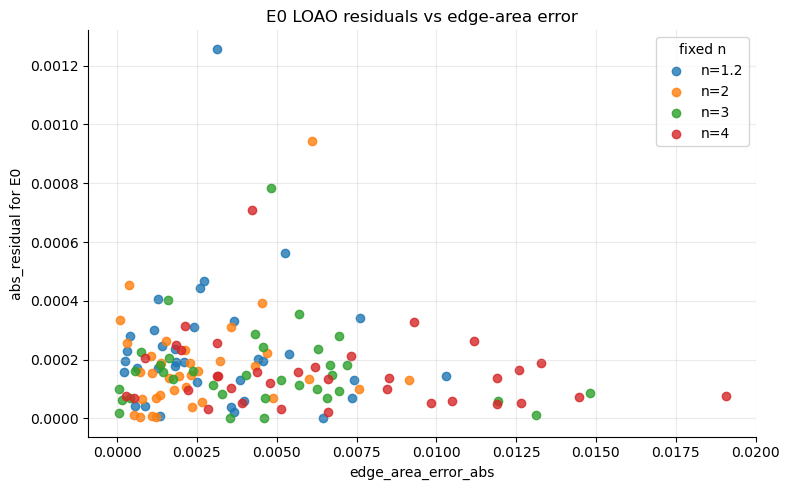

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\assets\ridge_e0_loao_abs_residual_vs_edge_error.png


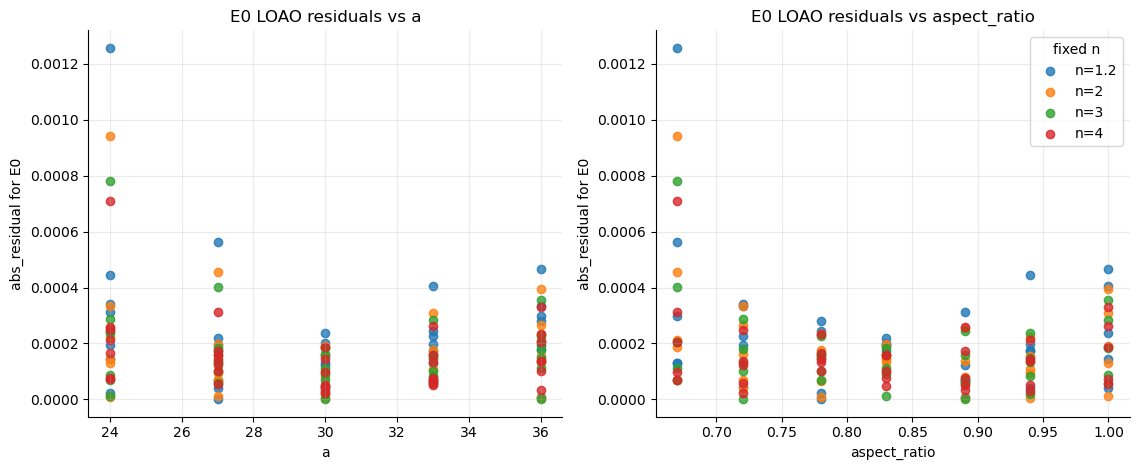

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\assets\ridge_e0_loao_abs_residual_vs_macro_params.png


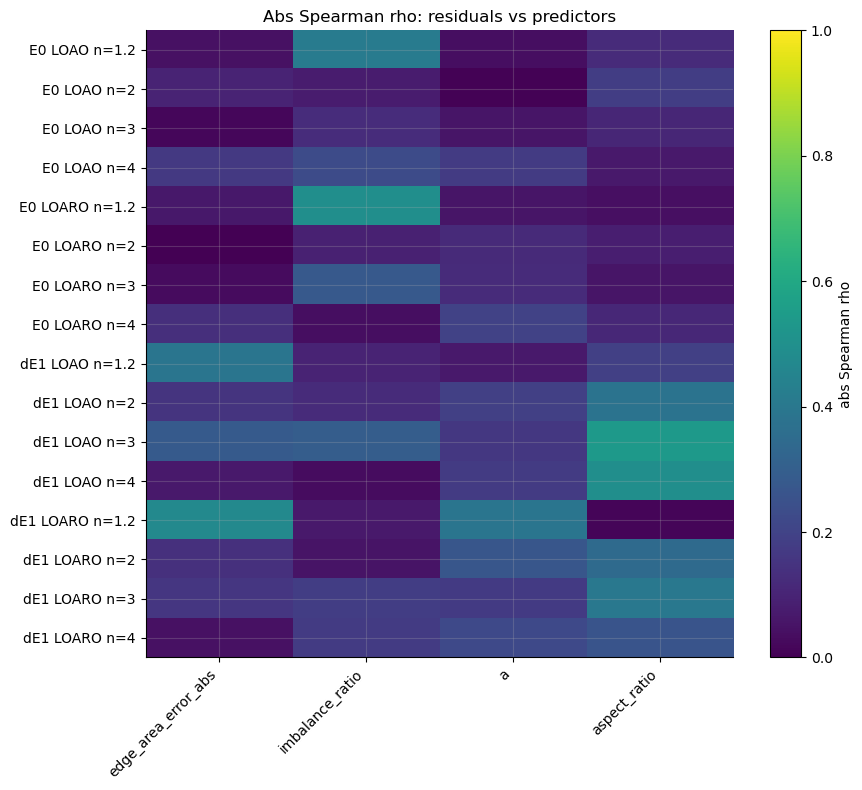

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\assets\ridge_residual_correlation_heatmap.png


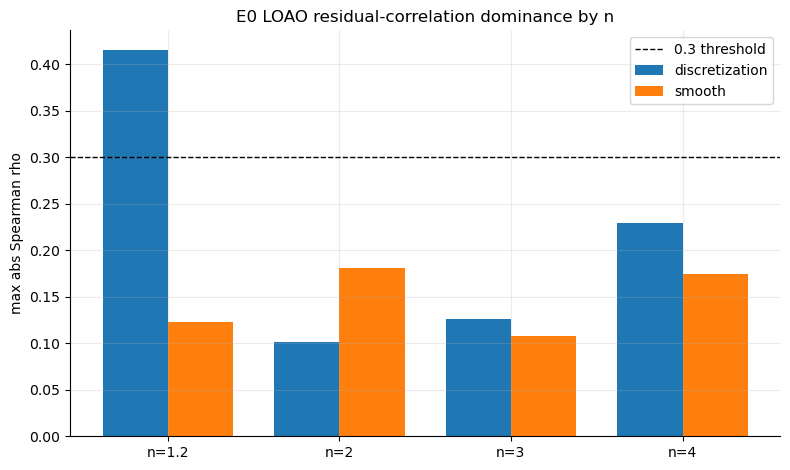

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\assets\ridge_residual_dominance_by_n.png


C:\Users\lalad\AppData\Local\Temp\ipykernel_23324\2867748628.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96))


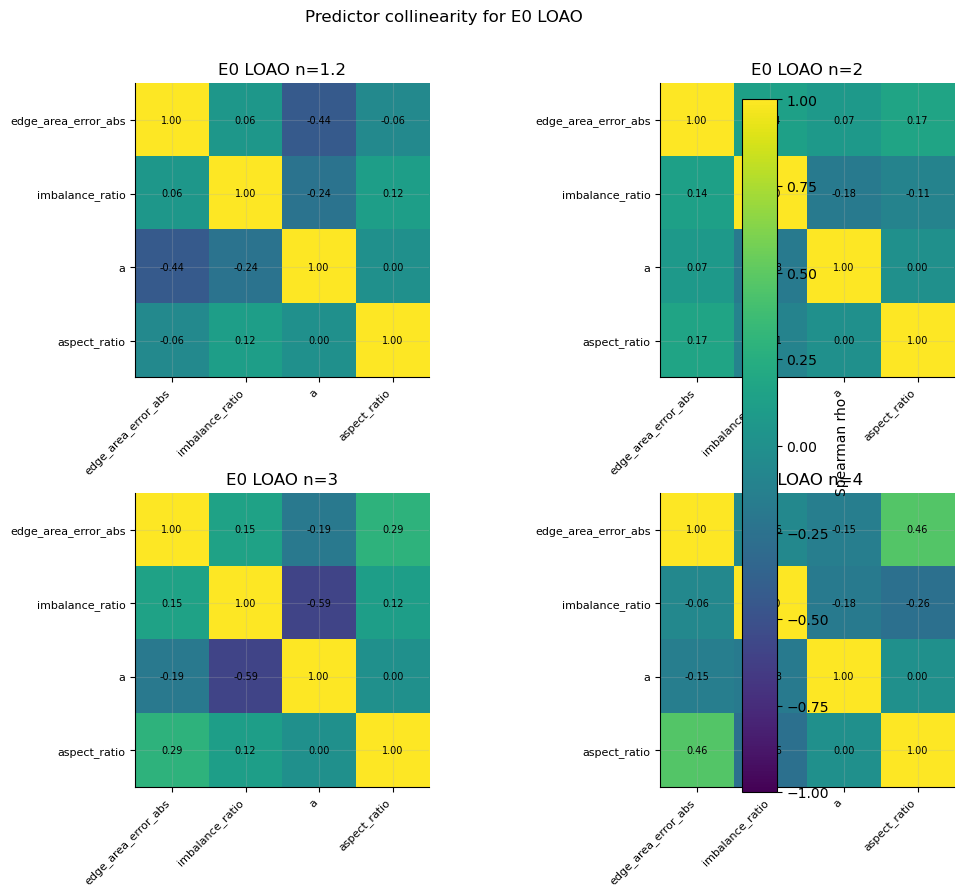

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\assets\ridge_predictor_collinearity_e0_loao.png


In [8]:
primary_oof = select_rows(oof_rows, target=PRIMARY_TARGET, protocol=PRIMARY_PROTOCOL)
fig, ax = plt.subplots(figsize=(8.0, 5.0))
for n_value in N_VALUES:
    subset = select_rows(primary_oof, n=n_value)
    ax.scatter(column(subset, "edge_area_error_abs"), column(subset, "abs_residual"), label=f"n={n_value:g}", alpha=0.8)
ax.set_xlabel("edge_area_error_abs")
ax.set_ylabel("abs_residual for E0")
ax.set_title("E0 LOAO residuals vs edge-area error")
ax.legend(title="fixed n")
fig.tight_layout()
edge_plot_path = ASSET_DIR / "ridge_e0_loao_abs_residual_vs_edge_error.png"
fig.savefig(edge_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {edge_plot_path}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for n_value in N_VALUES:
    subset = select_rows(primary_oof, n=n_value)
    axes[0].scatter(column(subset, "a"), column(subset, "abs_residual"), label=f"n={n_value:g}", alpha=0.8)
    axes[1].scatter(column(subset, "aspect_ratio"), column(subset, "abs_residual"), label=f"n={n_value:g}", alpha=0.8)
axes[0].set_xlabel("a")
axes[0].set_ylabel("abs_residual for E0")
axes[0].set_title("E0 LOAO residuals vs a")
axes[1].set_xlabel("aspect_ratio")
axes[1].set_ylabel("abs_residual for E0")
axes[1].set_title("E0 LOAO residuals vs aspect_ratio")
axes[1].legend(title="fixed n")
fig.tight_layout()
macro_plot_path = ASSET_DIR / "ridge_e0_loao_abs_residual_vs_macro_params.png"
fig.savefig(macro_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {macro_plot_path}")

heatmap_rows = [(target, protocol, n_value) for target in TARGETS for protocol in PROTOCOLS for n_value in N_VALUES]
heatmap_matrix = np.empty((len(heatmap_rows), len(PREDICTOR_VARIABLES)), dtype=float)
for i, (target, protocol, n_value) in enumerate(heatmap_rows):
    for j, variable in enumerate(PREDICTOR_VARIABLES):
        match = [row for row in correlation_rows if row["target"] == target and row["protocol"] == protocol and isclose_value(row["n"], n_value) and row["variable"] == variable][0]
        heatmap_matrix[i, j] = float(match["abs_spearman_rho"])
fig, ax = plt.subplots(figsize=(9.0, 8.0))
im = ax.imshow(heatmap_matrix, aspect="auto", vmin=0.0, vmax=1.0)
ax.set_xticks(np.arange(len(PREDICTOR_VARIABLES)))
ax.set_xticklabels(PREDICTOR_VARIABLES, rotation=45, ha="right")
ax.set_yticks(np.arange(len(heatmap_rows)))
ax.set_yticklabels([f"{target} {protocol} n={n:g}" for target, protocol, n in heatmap_rows])
ax.set_title("Abs Spearman rho: residuals vs predictors")
fig.colorbar(im, ax=ax, label="abs Spearman rho")
fig.tight_layout()
heatmap_plot_path = ASSET_DIR / "ridge_residual_correlation_heatmap.png"
fig.savefig(heatmap_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {heatmap_plot_path}")

primary_summary = select_rows(hypothesis_rows, target=PRIMARY_TARGET, protocol=PRIMARY_PROTOCOL)
x = np.arange(len(primary_summary)); width = 0.38
fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.bar(x - width / 2.0, [row["max_abs_rho_discretization"] for row in primary_summary], width, label="discretization")
ax.bar(x + width / 2.0, [row["max_abs_rho_smooth"] for row in primary_summary], width, label="smooth")
ax.axhline(MEANINGFUL_RHO_THRESHOLD, linestyle="--", linewidth=1, color="black", label="0.3 threshold")
ax.set_xticks(x)
ax.set_xticklabels([f"n={row['n']:g}" for row in primary_summary])
ax.set_ylabel("max abs Spearman rho")
ax.set_title("E0 LOAO residual-correlation dominance by n")
ax.legend()
fig.tight_layout()
dominance_plot_path = ASSET_DIR / "ridge_residual_dominance_by_n.png"
fig.savefig(dominance_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {dominance_plot_path}")

predictor_labels = PREDICTOR_VARIABLES
fig, axes = plt.subplots(2, 2, figsize=(10.5, 9.0))
for ax, n_value in zip(axes.ravel(), N_VALUES):
    matrix = np.eye(len(predictor_labels), dtype=float)
    col_rows = subset_collinearity_rows(PRIMARY_TARGET, PRIMARY_PROTOCOL, n_value)
    for i, var1 in enumerate(predictor_labels):
        for j, var2 in enumerate(predictor_labels):
            if i == j:
                matrix[i, j] = 1.0
            elif i < j:
                signed = math.nan
                for row in col_rows:
                    if {row["variable_1"], row["variable_2"]} == {var1, var2}:
                        signed = float(row["spearman_rho"])
                matrix[i, j] = signed; matrix[j, i] = signed
    im = ax.imshow(matrix, vmin=-1.0, vmax=1.0)
    ax.set_title(f"E0 LOAO n={n_value:g}")
    ax.set_xticks(np.arange(len(predictor_labels)))
    ax.set_yticks(np.arange(len(predictor_labels)))
    ax.set_xticklabels(predictor_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(predictor_labels, fontsize=8)
    for i in range(len(predictor_labels)):
        for j in range(len(predictor_labels)):
            value = matrix[i, j]
            ax.text(j, i, "NaN" if math.isnan(value) else f"{value:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=axes.ravel().tolist(), label="Spearman rho")
fig.suptitle("Predictor collinearity for E0 LOAO", y=0.98)
fig.tight_layout(rect=(0, 0, 1, 0.96))
collinearity_plot_path = ASSET_DIR / "ridge_predictor_collinearity_e0_loao.png"
fig.savefig(collinearity_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {collinearity_plot_path}")

## Conclusion

In [9]:
primary_support_count = num_n_classes_with_meaningful_discretization_support
primary_dominate_count = num_n_classes_where_discretization_dominates
primary_high_col_count = num_n_classes_with_high_collinearity
primary_winning_col_count = num_n_classes_with_winning_discretization_collinear_with_smooth
primary_best_disc_variables = [row["best_discretization_variable"] for row in primary_rows]
variable_counts = {variable: primary_best_disc_variables.count(variable) for variable in DISCRETIZATION_VARIABLES}
most_common_disc_variable = max(variable_counts, key=variable_counts.get)
smooth_dominate_count = len(primary_rows) - primary_dominate_count

de1_loao_rows = select_rows(hypothesis_rows, target="dE1", protocol="LOAO")
de1_loaro_rows = select_rows(hypothesis_rows, target="dE1", protocol="LOARO")
de1_loao_support_count = int(sum(row["meaningful_discretization_support"] for row in de1_loao_rows))
de1_loaro_support_count = int(sum(row["meaningful_discretization_support"] for row in de1_loaro_rows))

n12_imbalance_row = [
    row for row in correlation_rows
    if row["target"] == PRIMARY_TARGET
    and row["protocol"] == PRIMARY_PROTOCOL
    and isclose_value(row["n"], 1.2)
    and row["variable"] == "imbalance_ratio"
][0]
n12_imbalance_rho = float(n12_imbalance_row["spearman_rho"])
n12_imbalance_p = float(n12_imbalance_row["p_value"])

if primary_hypothesis_supported and primary_winning_col_count == 0 and primary_high_col_count == 0:
    conclusion_lead = "The result supports, but does not prove, the interpretation that remaining Ridge errors are associated with edge-discretization diagnostics."
elif primary_hypothesis_supported:
    conclusion_lead = "The result satisfies the correlation criterion but is suggestive rather than cleanly separable, because the winning discretization variables are collinear with smooth macro-parameters in some n-classes."
else:
    conclusion_lead = "The hypothesis that Ridge residuals are primarily explained by edge-discretization diagnostics was not supported by the pre-registered criterion."

conclusion = f"""
{conclusion_lead}

- `imbalance_ratio` and `abs_delta_N_over_N` are identical in this dataset because both are defined as `abs(delta_N) / N_sites`.
- Therefore, only two independent discretization diagnostics are used in the final correlation ranking: `edge_area_error_abs` and `imbalance_ratio`.
- Primary setting: target `E0`, protocol `LOAO`.
- Primary hypothesis supported: {primary_hypothesis_supported}.
- Discretization dominated smooth macro-parameters in {primary_dominate_count} of 4 n-classes.
- Meaningful discretization support was found in {primary_support_count} of 4 n-classes.
- Meaningful discretization support appears only for `n = 1.2` in the primary setting.
- The only practically meaningful primary result is the correlation between E0/LOAO Ridge residuals and `imbalance_ratio` for `n = 1.2`: |rho| = {abs(n12_imbalance_rho):.3f} (rho = {n12_imbalance_rho:.3f}), p = {n12_imbalance_p:.3f}.
- For `n >= 2`, the remaining Ridge residuals are not systematically explained by the selected discretization diagnostics in this analysis.
- Predictor high-collinearity appeared in {primary_high_col_count} of 4 primary n-classes.
- Winning discretization variables were collinear with smooth macro-parameters in {primary_winning_col_count} of 4 primary n-classes.
- The most frequent winning discretization variable in the primary rows was `{most_common_disc_variable}` ({variable_counts[most_common_disc_variable]} of 4 n-classes).
- Smooth macro-parameters dominated instead in {smooth_dominate_count} of 4 primary n-classes.
- Secondary dE1 analysis: meaningful discretization support appeared in {de1_loao_support_count} of 4 LOAO n-classes and {de1_loaro_support_count} of 4 LOARO n-classes. These secondary results are diagnostic only and do not change the primary decision.

Limitations: Spearman correlations are diagnostic associations, not causal evidence. The residuals are not fully explained by these variables, and collinearity among predictors limits clean separation of edge-discretization effects from smooth macro-parameter effects. This analysis does not show that the physics-informed feature set is optimal, does not make claims about MLPs in all contexts, and does not replace direct Kwant calculations.
"""

display(Markdown(conclusion))


The hypothesis that Ridge residuals are primarily explained by edge-discretization diagnostics was not supported by the pre-registered criterion.

- `imbalance_ratio` and `abs_delta_N_over_N` are identical in this dataset because both are defined as `abs(delta_N) / N_sites`.
- Therefore, only two independent discretization diagnostics are used in the final correlation ranking: `edge_area_error_abs` and `imbalance_ratio`.
- Primary setting: target `E0`, protocol `LOAO`.
- Primary hypothesis supported: False.
- Discretization dominated smooth macro-parameters in 3 of 4 n-classes.
- Meaningful discretization support was found in 1 of 4 n-classes.
- Meaningful discretization support appears only for `n = 1.2` in the primary setting.
- The only practically meaningful primary result is the correlation between E0/LOAO Ridge residuals and `imbalance_ratio` for `n = 1.2`: |rho| = 0.416 (rho = -0.416), p = 0.013.
- For `n >= 2`, the remaining Ridge residuals are not systematically explained by the selected discretization diagnostics in this analysis.
- Predictor high-collinearity appeared in 0 of 4 primary n-classes.
- Winning discretization variables were collinear with smooth macro-parameters in 0 of 4 primary n-classes.
- The most frequent winning discretization variable in the primary rows was `imbalance_ratio` (3 of 4 n-classes).
- Smooth macro-parameters dominated instead in 1 of 4 primary n-classes.
- Secondary dE1 analysis: meaningful discretization support appeared in 1 of 4 LOAO n-classes and 1 of 4 LOARO n-classes. These secondary results are diagnostic only and do not change the primary decision.

Limitations: Spearman correlations are diagnostic associations, not causal evidence. The residuals are not fully explained by these variables, and collinearity among predictors limits clean separation of edge-discretization effects from smooth macro-parameter effects. This analysis does not show that the physics-informed feature set is optimal, does not make claims about MLPs in all contexts, and does not replace direct Kwant calculations.
